In [1]:
# Import public packages and functions
import os
import pandas as pd
import numpy as np
import sys
import json
from pathlib import Path
from scipy import signal

import seaborn as sns
import matplotlib.pyplot as plt
import scikit_posthocs as sp

from joblib import Parallel, delayed
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

# inserting the lib folder to the compiler
sys.path.insert(0, './lib')
sys.path.insert(0, './utils/')

import utils_io, utils_trgc

from lib_data import DATA_IO

In [2]:
PATH_CURR = os.path.abspath(os.curdir)    # current code
PATH      = (str(Path(PATH_CURR).parent)) # data repository: upper directory where datasets situated
fs        = 2048

# 1. Data Load & Preprocess

In [3]:
# load ECoG events
EVENTS_ECOG            = utils_io.load_ECoG_events(event_category="tapping", fs=2048)
EVENTS_ECOG_LID        = EVENTS_ECOG['controlateral']['LID']
EVENTS_ECOG_noLID      = EVENTS_ECOG['controlateral']['noLID']
# load LFP events
EVENTS_LFP             = utils_io.load_LFP_events(event_category="tapping", stn_areas=["motor"], fs=2048)
EVENTS_LFP_MOTOR_LID   = EVENTS_LFP['motor']['controlateral']['LID']
EVENTS_LFP_MOTOR_noLID = EVENTS_LFP['motor']['controlateral']['noLID']

In [6]:
# add state information
EVENTS_ECOG_noLID["severity"]                                                              = "MED-OFF"
EVENTS_ECOG_noLID.loc[(EVENTS_ECOG_noLID['event_start_time'] >= 30), 'severity']           = 'MED-ON'
EVENTS_ECOG_LID["severity"]                                                                = "LID"
EVENTS_LFP_MOTOR_noLID["severity"]                                                         = "MED-OFF"
EVENTS_LFP_MOTOR_noLID.loc[(EVENTS_LFP_MOTOR_noLID['event_start_time'] >= 30), 'severity'] = 'MED-ON'
EVENTS_LFP_MOTOR_LID["severity"]                                                           = "LID"

dataset_LFP  = pd.concat([EVENTS_LFP_MOTOR_noLID, EVENTS_LFP_MOTOR_LID], ignore_index=True)
dataset_ECOG = pd.concat([EVENTS_ECOG_LID, EVENTS_ECOG_noLID], ignore_index=True)

dataset_LFP  = dataset_LFP[dataset_LFP.patient.isin(dataset_ECOG.patient.unique().tolist())]
dataset_LFP.reset_index(drop=True, inplace=True)

dataset_LFP  = dataset_LFP[['patient', 'event_no', 'LFP_hemisphere', 'LFP_channel', 'pre_event_recording', 'event_recording', 'post_event_recording', 'severity']]
dataset_ECOG = dataset_ECOG[['patient', 'event_no', 'ECoG_hemisphere', 'ECoG_channel', 'pre_event_recording', 'event_recording', 'post_event_recording', 'severity']]

del EVENTS_ECOG, EVENTS_ECOG_LID, EVENTS_ECOG_noLID, EVENTS_LFP, EVENTS_LFP_MOTOR_LID, EVENTS_LFP_MOTOR_noLID

# 2. Time-Reversed Granger Causality

## 2.1 Tapping Activity

In [ ]:
connectivity_side = "ipsilateral"
data_gc           = []

for state in ["MED-OFF", "MED-ON", "LID"]:
    for direction in ["lfp->ecog", "ecog->lfp"]:
        for patient in dataset_ECOG[dataset_ECOG.severity==state].patient.unique():
            for segment in ["pre_event", "event", "post_event"]:

                print(f"processing patient {patient} | {direction} direction | {state} state | {segment} segment... ")
                patient_gc = utils_trgc.measure_granger_causality_between_STN_and_cortex(dataset_LFP       = dataset_LFP, 
                                                                                         dataset_ECOG      = dataset_ECOG, 
                                                                                         state             = state, 
                                                                                         direction         = direction, 
                                                                                         patient           = patient, 
                                                                                         segment           = segment, 
                                                                                         connectivity_side = connectivity_side,
                                                                                         fs                = fs, 
                                                                                         n_iteration       = 100)
                if not (np.isscalar(patient_gc) and np.isnan(patient_gc)):
                    data_gc.append(patient_gc)

data_gc = pd.concat(data_gc, ignore_index=True)

processing patient 009 | lfp->ecog direction | MED-OFF state | pre_event segment... 
>>> pre-event recordings have consistent length  : True
>>> >>> bootstrap testing with 100 iterations
>>> >>> >>> 100 iteration completed...
processing patient 009 | lfp->ecog direction | MED-OFF state | event segment... 
>>> event recordings have consistent length      : True
>>> >>> bootstrap testing with 100 iterations
>>> >>> >>> 100 iteration completed...
processing patient 009 | lfp->ecog direction | MED-OFF state | post_event segment... 
>>> post event recordings have consistent length : True
>>> >>> bootstrap testing with 100 iterations
>>> >>> >>> 100 iteration completed...
processing patient 010 | lfp->ecog direction | MED-OFF state | pre_event segment... 
>>> >>> >>> Patient 010 does not have LFP or ECOG recordings for MED-OFF state to estimate connectivity...
processing patient 010 | lfp->ecog direction | MED-OFF state | event segment... 
>>> >>> >>> Patient 010 does not have LFP or ECOG re

In [8]:
data_gc.to_pickle(DATA_IO.path_events + "granger_causality/ipsilateral_connectivity.pkl")

## 2.2 Baseline Recordings

In [3]:
baseline_gc = utils_connectivity.measure_baseline_granger_causality_between_STN_and_cortex(connectivity_side="ipsilateral", fs=fs)
baseline_gc.to_pickle(DATA_IO.path_events + "granger_causality/baseline_ipsilateral_connectivity.pkl")

Patient 008: does not have right hemisphere baseline recordings
Patient 009: does not have right hemisphere baseline recordings
Patient 010: does not have left hemisphere baseline recordings
Patient 012: does not have left hemisphere baseline recordings
Patient 013: does not have left hemisphere baseline recordings
Patient 014: does not have left hemisphere baseline recordings
Patient 016: does not have left hemisphere baseline recordings
Patient 017: does not have left hemisphere baseline recordings
Patient 020: does not have left hemisphere baseline recordings
Patient 021: does not have left hemisphere baseline recordings
Patient 022: does not have left hemisphere baseline recordings
Patient 023: does not have left hemisphere baseline recordings
Patient 101: does not have right hemisphere baseline recordings
Patient 101: does not have left hemisphere baseline recordings
Patient 102: does not have right hemisphere baseline recordings
Patient 102: does not have left hemisphere baseline

## 2.3 Normalization

In [3]:
baseline_gc   = pd.read_pickle(DATA_IO.path_events + "granger_causality/baseline_ipsilateral_connectivity.pkl")
taps_gc       = pd.read_pickle(DATA_IO.path_events + "granger_causality/ipsilateral_connectivity.pkl")
normalized_gc = utils_connectivity.normalize_gc_by_baseline(taps_gc, baseline_gc)

# 4. Statistical Test

In [11]:
import statsmodels.formula.api as smf

dataset = normalized_gc.copy()
state   = "LID"
segment = "pre_event"
data    = dataset[(dataset.state==state) & (dataset.segment==segment)].copy()


model   = smf.mixedlm("gc_theta ~ direction", data, groups=data["patient"])  # random intercept for each patient
result  = model.fit()
print(result.summary())

                  Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      gc_theta    
No. Observations:      342          Method:                  REML        
No. Groups:            7            Scale:                   3010306.1659
Min. group size:       20           Log-Likelihood:          -3028.7274  
Max. group size:       110          Converged:               Yes         
Mean group size:       48.9                                              
-------------------------------------------------------------------------
                         Coef.    Std.Err.   z    P>|z|  [0.025   0.975] 
-------------------------------------------------------------------------
Intercept                1024.029  264.328  3.874 0.000  505.955 1542.103
direction[T.lfp->ecog]   -226.767  187.639 -1.209 0.227 -594.532  140.998
Group Var              337878.495  147.433                               



## 4.1 Within Clinical State - Difference Between Directionality

In [31]:
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf

def built_lme_and_fit(dataset, state, segment, feature):
    
    data    = dataset[(dataset.state==state) & (dataset.segment==segment)].copy()

    # ensuring categorical encoding
    data["direction"] = data["direction"].astype("category")
    data["patient"]   = data["patient"].astype("category")

    # fitting the model
    model   = smf.mixedlm(f"{feature} ~ direction", data, groups=data["patient"])  # random intercept for each patient
    result  = model.fit()

    row                = dict()
    row["feature"]     = feature
    row["state"]       = state
    row["segment"]     = segment
    row["coefficient"] = result.fe_params["direction[T.lfp->ecog]"]
    row["pvalue"]      = result.pvalues["direction[T.lfp->ecog]"]
    row["std_err"]     = result.bse["direction[T.lfp->ecog]"]
    row["z_score"]     = row["coefficient"]/row["std_err"]

    # negative coefficients mean that information flow from stn->cortex is lower than cortex->stn
    return pd.DataFrame([row])

In [ ]:
features    = ["gc_theta","gc_alpha","gc_beta_low","gc_beta_high","gc_gamma"]
lme_results = []

for state in ["MED-OFF", "MED-ON", "LID"]:
    for segment in ["pre_event", "event", "post_event"]:
        for feature in features:
            lme_results.append(built_lme_and_fit(dataset=normalized_gc, state=state, segment=segment, feature=feature))

lme_results                     = pd.concat(lme_results, ignore_index=True)

# segment-based correction
lme_results["pvalue_corrected"] = (lme_results.groupby("segment")["pvalue"].transform(lambda x: multipletests(x, method="holm")[1]))

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

def plot_significance_heatmap(df, axis):

    features    = df['feature'].unique()
    states      = df['state'].unique()
    color_data  = pd.DataFrame(index=states, columns=features, data=0.0)
    text_matrix = pd.DataFrame("", index=states, columns=features)

    # Map significance to discrete levels
    for _, row in df.iterrows():
        p    = row['pvalue_corrected']
        coef = row['coefficient']

        if   (p <= 0.001): level = 3
        elif (p <= 0.010): level = 2
        elif (p <= 0.050): level = 1
        else             : level = 0

        # Assign shading
        color_data.loc[row['state'], row['feature']] = level
        # Mark positive coefficients
        if(coef > 0 and level > 0): text_matrix.loc[row['state'], row['feature']] = "*"

    # Define discrete colormap
    colors = ['white', '#caf0f8', '#00b4d8', '#1d3557']
    cmap   = ListedColormap(colors)
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
    norm   = BoundaryNorm(bounds, cmap.N)

    # Draw heatmap on provided axis
    axis   = sns.heatmap(color_data.astype(float), cmap=cmap, norm=norm,linewidths=0.5, linecolor='white', cbar=False, ax=axis)

    # Add "*" for positive coefficients
    for i, state in enumerate(states):
        for j, feature in enumerate(features):
            if text_matrix.loc[state, feature] != "":
                axis.text(j + 0.5, i + 0.5, text_matrix.loc[state, feature], ha='center', va='center', color='red',fontsize=5, fontweight='bold')
    return axis

In [ ]:
plt      = utils_plotting.get_figure_template()
ax_pre   = plt.subplot2grid((80, 45), (0, 0) , colspan=15, rowspan=6)
ax_event = plt.subplot2grid((80, 45), (0, 15), colspan=15, rowspan=6)
ax_post  = plt.subplot2grid((80, 45), (0, 30), colspan=15, rowspan=6)

ax_pre   = plot_significance_heatmap(lme_results[lme_results.segment=="pre_event"] , axis=ax_pre)
ax_event = plot_significance_heatmap(lme_results[lme_results.segment=="event"]     , axis=ax_event)
ax_post  = plot_significance_heatmap(lme_results[lme_results.segment=="post_event"], axis=ax_post)

ax_pre   = utils_plotting.set_axis(ax_pre)
ax_event = utils_plotting.set_axis(ax_event)
ax_post  = utils_plotting.set_axis(ax_post)

plt.savefig(DATA_IO.path_figure + "granger_causality/within_state_directionality_differences.svg", dpi=300)

# 5. Plotting

In [13]:
def plot_granger_causality(dataset, state, segment, axis):

    df_filtered = dataset[(dataset["state"]==state) & (dataset["segment"]==segment)]
    
    gc_columns  = ['gc_theta', 'gc_alpha', 'gc_beta_low', 'gc_beta_high', 'gc_gamma']
    gc_long     = df_filtered.melt(id_vars=['direction'], value_vars=gc_columns, var_name='GC_type', value_name='GC_value')
    
    axis        = sns.boxplot(data=gc_long, x='GC_type', y='GC_value', hue='direction', palette='Set2', whis=0, showfliers=False, legend=False, ax=axis)
    axis.set_title(f"{state} | {segment}", fontsize=utils_plotting.LABEL_SIZE)
    axis.set_xlabel("Frequency Bands")
    axis.set_ylabel("GC % Change DOPA-OFF")
    axis.tick_params(axis='x', rotation=0)
    axis.set_xticklabels(['theta', 'alpha', 'beta_low', 'beta_high', 'gamma'], rotation=90) 
    #axis.legend(title='connectivity direction', bbox_to_anchor=(1.05, 1), loc='upper left')
    return axis


<Figure size 640x480 with 0 Axes>

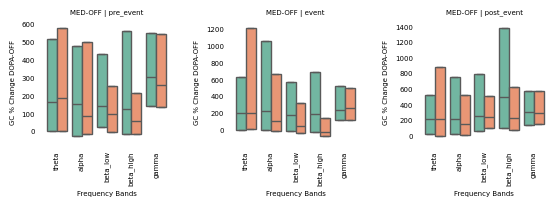

In [37]:
plt      = utils_plotting.get_figure_template()
ax_pre   = plt.subplot2grid((80, 45), (0, 0) , colspan=10, rowspan=15)
ax_event = plt.subplot2grid((80, 45), (0, 15), colspan=10, rowspan=15)
ax_post  = plt.subplot2grid((80, 45), (0, 30), colspan=10, rowspan=15)
    
ax_pre   = plot_granger_causality(normalized_gc, segment="pre_event" , state="MED-OFF", axis=ax_pre)
ax_event = plot_granger_causality(normalized_gc, segment="event"     , state="MED-OFF", axis=ax_event)
ax_post  = plot_granger_causality(normalized_gc, segment="post_event", state="MED-OFF", axis=ax_post)

#ax_pre.set_ylim([0,0.05])
#ax_event.set_ylim([0,0.05])
#ax_post.set_ylim([0,0.05])

utils_plotting.set_axis(ax_pre)
utils_plotting.set_axis(ax_event)
utils_plotting.set_axis(ax_post)

plt.savefig(DATA_IO.path_figure + "granger_causality/MED-OFF.svg", dpi=300)

<Figure size 640x480 with 0 Axes>

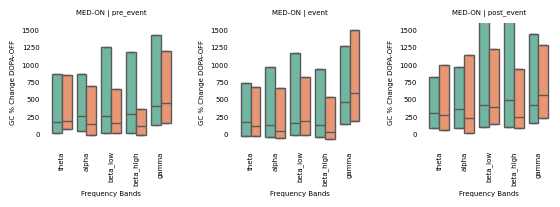

In [47]:
plt      = utils_plotting.get_figure_template()
ax_pre   = plt.subplot2grid((80, 45), (0, 0) , colspan=10, rowspan=15)
ax_event = plt.subplot2grid((80, 45), (0, 15), colspan=10, rowspan=15)
ax_post  = plt.subplot2grid((80, 45), (0, 30), colspan=10, rowspan=15)
    
ax_pre   = plot_granger_causality(normalized_gc, segment="pre_event" , state="MED-ON", axis=ax_pre)
ax_event = plot_granger_causality(normalized_gc, segment="event"     , state="MED-ON", axis=ax_event)
ax_post  = plot_granger_causality(normalized_gc, segment="post_event", state="MED-ON", axis=ax_post)

ax_pre.set_ylim([-100,1600])
ax_event.set_ylim([-100,1600])
ax_post.set_ylim([-100,1600])

utils_plotting.set_axis(ax_pre)
utils_plotting.set_axis(ax_event)
utils_plotting.set_axis(ax_post)

plt.savefig(DATA_IO.path_figure + "granger_causality/MED-ON.svg", dpi=300)

<Figure size 640x480 with 0 Axes>

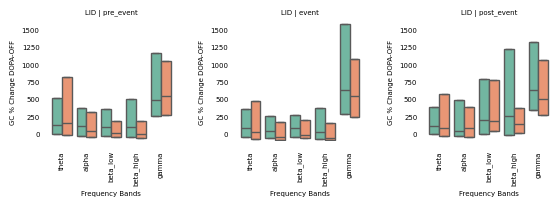

In [45]:
plt      = utils_plotting.get_figure_template()
ax_pre   = plt.subplot2grid((80, 45), (0, 0) , colspan=10, rowspan=15)
ax_event = plt.subplot2grid((80, 45), (0, 15), colspan=10, rowspan=15)
ax_post  = plt.subplot2grid((80, 45), (0, 30), colspan=10, rowspan=15)
    
ax_pre   = plot_granger_causality(normalized_gc, segment="pre_event" , state="LID", axis=ax_pre)
ax_event = plot_granger_causality(normalized_gc, segment="event"     , state="LID", axis=ax_event)
ax_post  = plot_granger_causality(normalized_gc, segment="post_event", state="LID", axis=ax_post)

ax_pre.set_ylim([-100,1600])
ax_event.set_ylim([-100,1600])
ax_post.set_ylim([-100,1600])

utils_plotting.set_axis(ax_pre)
utils_plotting.set_axis(ax_event)
utils_plotting.set_axis(ax_post)

plt.savefig(DATA_IO.path_figure + "granger_causality/LID.svg", dpi=300)